In [1]:
!pip install nibabel torch torchvision
!pip install lpips
!pip install torchio
# =============================================================================
# IMPORTS - Medical Image Translation Metrics
# =============================================================================

# -------------------------
# Standard Library
# -------------------------
import math
import random
import itertools
import functools
import os, glob
import gc

# -------------------------
# Numerical & Scientific Computing
# -------------------------
import numpy as np
from scipy.io import loadmat
from scipy.stats import pearsonr, entropy
from scipy.ndimage import convolve

# -------------------------
# Image Processing
# -------------------------
from PIL import Image
import imageio
import matplotlib.pyplot as plt

# -------------------------
# Medical Imaging
# -------------------------
import nibabel as nib

# -------------------------
# Machine Learning - scikit-learn
# -------------------------
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

# -------------------------
# Deep Learning - PyTorch
# -------------------------
import torch
import torch as pt  # Alternative import name used in FSIM
import torch.nn as nn
from torch import optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as FUN  # Alternative import name used in FSIM
import torch.nn.functional as F
from torchvision import transforms
import torchio as tio

# -------------------------
# Perceptual Metrics
# -------------------------
import lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.0 MB/s eta 0:00:00


In [2]:
# Forza la pulizia della RAM di sistema (Garbage Collector)
gc.collect()

# Svuota la memoria residua della GPU
torch.cuda.empty_cache()

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [4]:
class UnetSkipConnectionBlock3D(nn.Module):
    """Costruisce un blocco della U-Net con skip connections (stile originale Pix2Pix)"""
    def __init__(self, outer_nc, inner_nc, input_nc=None,
                 submodule=None, outermost=False, innermost=False, norm_layer=nn.InstanceNorm3d, use_dropout=False):
        super(UnetSkipConnectionBlock3D, self).__init__()
        self.outermost = outermost
        if type(norm_layer) == functools.partial:
            use_bias = norm_layer.func == nn.InstanceNorm3d
        else:
            use_bias = norm_layer == nn.InstanceNorm3d
            
        if input_nc is None:
            input_nc = outer_nc
            
        downconv = nn.Conv3d(input_nc, inner_nc, kernel_size=4, stride=2, padding=1, bias=use_bias)
        downrelu = nn.LeakyReLU(0.2, True)
        downnorm = norm_layer(inner_nc)
        uprelu = nn.ReLU(True)
        upnorm = norm_layer(outer_nc)

        if outermost:
            upconv = nn.ConvTranspose3d(inner_nc * 2, outer_nc, kernel_size=4, stride=2, padding=1)
            down = [downconv]
            up = [uprelu, upconv, nn.Tanh()]
            model = down + [submodule] + up
        elif innermost:
            upconv = nn.ConvTranspose3d(inner_nc, outer_nc, kernel_size=4, stride=2, padding=1, bias=use_bias)
            down = [downrelu, downconv]
            up = [uprelu, upconv, upnorm]
            model = down + up
        else:
            upconv = nn.ConvTranspose3d(inner_nc * 2, outer_nc, kernel_size=4, stride=2, padding=1, bias=use_bias)
            down = [downrelu, downconv, downnorm]
            up = [uprelu, upconv, upnorm]
            if use_dropout:
                model = down + [submodule] + up + [nn.Dropout(0.5)]
            else:
                model = down + [submodule] + up

        self.model = nn.Sequential(*model)

    def forward(self, x):
        if self.outermost:
            return self.model(x)
        else:   # Aggiunge la skip connection
            return torch.cat([x, self.model(x)], 1)

class UNetGenerator3D(nn.Module):
    """Versione 3D del generatore Pix2Pix originale (neoamos)"""
    def __init__(self, in_channels=1, out_channels=1, num_downs=7, features=64, norm_layer=nn.InstanceNorm3d, use_dropout=True):
        super(UNetGenerator3D, self).__init__()
        # Costruisce la U-Net ricorsivamente partendo dal centro (innermost)
        unet_block = UnetSkipConnectionBlock3D(features * 8, features * 8, input_nc=None, submodule=None, norm_layer=norm_layer, innermost=True)
        for i in range(num_downs - 5):
            unet_block = UnetSkipConnectionBlock3D(features * 8, features * 8, input_nc=None, submodule=unet_block, norm_layer=norm_layer, use_dropout=use_dropout)
        # Blocchi in risalita
        unet_block = UnetSkipConnectionBlock3D(features * 4, features * 8, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        unet_block = UnetSkipConnectionBlock3D(features * 2, features * 4, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        unet_block = UnetSkipConnectionBlock3D(features, features * 2, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        self.model = UnetSkipConnectionBlock3D(out_channels, features, input_nc=in_channels, submodule=unet_block, outermost=True, norm_layer=norm_layer)

    def forward(self, input):
        return self.model(input)

In [5]:
class PatchDiscriminator3D(nn.Module):
    """PatchGAN 3D classico basato su NLayerDiscriminator originale"""
    def __init__(self, in_channels=2, ndf=64, n_layers=3, norm_layer=nn.InstanceNorm3d):
        super(PatchDiscriminator3D, self).__init__()
        if type(norm_layer) == functools.partial:
            use_bias = norm_layer.func == nn.InstanceNorm3d
        else:
            use_bias = norm_layer == nn.InstanceNorm3d

        kw = 4
        padw = int(np.ceil((kw-1)/2))
        sequence = [nn.Conv3d(in_channels, ndf, kernel_size=kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        nf_mult = 1
        nf_mult_prev = 1
        
        for n in range(1, n_layers):  # Aumenta i canali gradualmente
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            sequence += [
                nn.Conv3d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=use_bias),
                norm_layer(ndf * nf_mult),
                nn.LeakyReLU(0.2, True)
            ]

        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n_layers, 8)
        sequence += [
            nn.Conv3d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=use_bias),
            norm_layer(ndf * nf_mult),
            nn.LeakyReLU(0.2, True)
        ]

        sequence += [nn.Conv3d(ndf * nf_mult, 1, kernel_size=3, stride=1, padding=padw)]  # output a 1 canale (patch map)
        self.model = nn.Sequential(*sequence)

    def forward(self, A, B):
        # Concatena input (T1) e target (FLAIR) sull'asse dei canali
        return self.model(torch.cat([A, B], dim=1))

In [6]:
def prepara_dataset_train_test(
    percentuale_train=1.0, 
    percentuale_test=1.0, 
    dir_B_train='/kaggle/input/datasets/pietrofilipposchgor/t1-flair/T1 - FLAIR/FLAIR',
    dir_A_train='/kaggle/input/datasets/pietrofilipposchgor/t2-train',
    file_codici_train='/kaggle/input/datasets/giuliasteiner/t2-flair-codici-comuni/lista_codici_TRAIN.txt',
    dir_B_test='/kaggle/input/datasets/pietrofilipposchgor/t1-flair-test/FLAIR',
    dir_A_test='/kaggle/input/datasets/pietrofilipposchgor/t2-test',
    file_codici_test='/kaggle/input/datasets/giuliasteiner/t2-flair-codici-comuni/lista_codici_TEST.txt',
    seed=SEED
): 
    """
    Legge i dati da cartelle distinte per train e test e restituisce 
    le due liste di soggetti TorchIO pronte per il Dataset.
    """
    
    # ==========================================
    # 0. IMPOSTAZIONE DEL SEED
    # ==========================================
    if seed is not None:
        random.seed(seed)
        print(f"-> Seed di randomizzazione impostato a: {seed}")

    # ==========================================
    # 1. LETTURA FILE E DIZIONARI (TRAINING SET)
    # ==========================================
    list_A_train = [f for f in os.listdir(dir_A_train) if f.endswith(('.nii', '.nii.gz'))]
    list_B_train = [f for f in os.listdir(dir_B_train) if f.endswith(('.nii', '.nii.gz'))]
    
    dict_A_train = {f.split('_')[0]: f for f in list_A_train}
    dict_B_train = {f.split('_')[0]: f for f in list_B_train}

    with open(file_codici_train, 'r') as f:
        codici_comuni_train = [line.strip() for line in f.readlines()]

    # ==========================================
    # 2. LETTURA FILE E DIZIONARI (TEST SET)
    # ==========================================
    list_A_test = [f for f in os.listdir(dir_A_test) if f.endswith(('.nii', '.nii.gz'))]
    list_B_test = [f for f in os.listdir(dir_B_test) if f.endswith(('.nii', '.nii.gz'))]
    
    dict_A_test = {f.split('_')[0]: f for f in list_A_test}
    dict_B_test = {f.split('_')[0]: f for f in list_B_test}

    with open(file_codici_test, 'r') as f:
        codici_comuni_test = [line.strip() for line in f.readlines()]

    # ==========================================
    # 3. CAMPIONAMENTO DEI CODICI (TRAIN / TEST)
    # ==========================================
    N_train = len(codici_comuni_train)
    N_test = len(codici_comuni_test)
    
    num_train = int(N_train * percentuale_train)
    num_test = int(N_test * percentuale_test)

    # Estraiamo i codici in modo indipendente dalle due liste
    codici_train = random.sample(codici_comuni_train, num_train)
    codici_test = random.sample(codici_comuni_test, num_test)

    print(f"Totale pazienti Train disponibili: {N_train} | Selezionati: {num_train}")
    print(f"Totale pazienti Test disponibili: {N_test} | Selezionati: {num_test}")

    # ==========================================
    # 4. CREAZIONE DELLE LISTE TORCHIO
    # ==========================================
    subjects_list_train = []
    subjects_list_test = []

    print("\nCreazione subjects_list_train in corso...")
    for codice in codici_train:
        path_A = os.path.join(dir_A_train, dict_A_train[codice])
        path_B = os.path.join(dir_B_train, dict_B_train[codice])
        
        subject = tio.Subject(
            A=tio.ScalarImage(path_A),
            B=tio.ScalarImage(path_B),
            nome_paziente=codice
        )
        subjects_list_train.append(subject)

    print("Creazione subjects_list_test in corso...")
    for codice in codici_test:
        path_A = os.path.join(dir_A_test, dict_A_test[codice])
        path_B = os.path.join(dir_B_test, dict_B_test[codice])
        
        subject = tio.Subject(
            A=tio.ScalarImage(path_A),
            B=tio.ScalarImage(path_B),
            nome_paziente=codice
        )
        subjects_list_test.append(subject)
        
    print("Liste create con successo!\n")

    return subjects_list_train, subjects_list_test

In [7]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
    elif classname.find('InstanceNorm3d') != -1:
        # Aggiungi il controllo per verificare se il layer ha pesi apprendibili
        if m.weight is not None:
            torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)

In [8]:
def plot_clinical_metrics(history, save_path=None):
    """
    Visualizza l'andamento delle metriche cliniche e opzionalmente salva l'immagine.
    
    Args:
        history (dict): Dizionario contenente le liste delle metriche.
        save_path (str, optional): Percorso (incluso nome file ed estensione) dove salvare il plot.
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle('Andamento Metriche Cliniche (Validazione Speciale)', fontsize=16)
    
    epochs = history['epoch']
    metrics = [
        ('mae', 'MAE (↓)', 'tab:red'),
        ('psnr', 'PSNR dB (↑)', 'tab:blue'),
        ('ssim', 'SSIM (↑)', 'tab:green'),
        ('ncc', 'NCC (↑)', 'tab:orange'),
        ('lpips', 'LPIPS (↓)', 'tab:purple'),
        ('fsim', 'FSIM (↑)', 'tab:olive')
    ]
    
    for i, (key, label, color) in enumerate(metrics):
        row, col = divmod(i, 3)
        ax = axes[row, col]
        # Verifichiamo che la metrica esista nella history per evitare errori
        if key in history:
            ax.plot(epochs, history[key], marker='o', linestyle='-', color=color)
            ax.set_title(label)
            ax.set_xlabel('Epoca')
            ax.grid(True, alpha=0.3)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Salvataggio se specificato
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Grafico salvato in: {save_path}")
        
    plt.show()

In [9]:
import torch
import torchio as tio
from torch.utils.data import Dataset

# ==========================================
# 2. CREAZIONE DEL WRAPPER DI ADATTAMENTO
# ==========================================
class TorchIOWrapper(Dataset):
    """
    Questo wrapper fa finta di essere il vecchio NiftiPairedDataset.
    Estrae il tensore nativo da TorchIO e permuta gli assi nella 
    forma corretta, così le funzioni di valutazione non vanno in errore.
    """
    def __init__(self, tio_dataset):
        self.tio_dataset = tio_dataset
        
    def __len__(self):
        return len(self.tio_dataset)
        
    def __getitem__(self, idx):
        subject = self.tio_dataset[idx]
        
        # TorchIO restituisce i volumi come [Canali, W, H, D].
        # Permutiamo gli assi in [Canali, D, H, W] usando gli indici (0, 3, 2, 1).
        img_A = subject['A'][tio.DATA].permute(0, 3, 2, 1)
        img_B = subject['B'][tio.DATA].permute(0, 3, 2, 1)
        
        # Restituisce un dizionario semplice come faceva il NiftiPairedDataset
        return {'A': img_A, 'B': img_B}



* epochs=1, batch_size=64, patches_per_pat = 8, patch_size=(64, 64, 64) -> 33 min  
* epochs=1, batch_size=64, patches_per_pat = 4, patch_size=(64, 64, 64) -> 21 min

In [10]:
def ssim_structure(img1, img2):
    """
    Compute the structural similarity index (SSIM) focusing only on the structure component.
    
    Parameters:
    - img1: First image (grayscale).
    - img2: Second image (grayscale).
    
    Returns:
    - Structural similarity index focusing only on structure.
    """
    # Ensure the input images are in float format
    #img1 = img1.astype(np.float64)
    #img2 = img2.astype(np.float64)
    
    # Define constants for numerical stability
    #C3 = 1e-15
    C3 = (0.03 * (2**8 - 1))**2 / 2

    # Compute the mean of the images
    mu1 = np.mean(img1)
    mu2 = np.mean(img2)
    
    # Compute the standard deviation of the images
    sigma1 = np.std(img1)
    sigma2 = np.std(img2)
    
    # Compute the covariance between the images
    covariance = np.mean((img1 - mu1) * (img2 - mu2))
    
    # Compute the structural similarity index focusing only on the structure component
    ssim_structure_component = (covariance + C3) / (sigma1 * sigma2 + C3)
    
    return ssim_structure_component

def normalize_image(image):
    """ Normalize image to the range [0, 1]. """
    image = image.astype(np.float64)
    return 255*(image - np.min(image)) / (np.max(image) - np.min(image))

def calculate_3d_ssim(image1, image2):
    assert image1.shape == image2.shape, "Input images must have the same dimensions"
    
    # Normalize images to [0, 1] range
    image1 = normalize_image(image1)
    image2 = normalize_image(image2)
    
    # Dimensions of the 3D images
    H, W, D = image1.shape
    
    # Calculate SSIM for each slice along the third axis (depth)
    ssim_values = []
    for i in range(D):
        slice1 = image1[:, :, i]
        slice2 = image2[:, :, i]
        slice_ssim = ssim_structure(slice1, slice2)  # data_range is 1 since images are normalized
        ssim_values.append(slice_ssim)
        
    for i in range(W):
        slice1 = image1[:, i, :]
        slice2 = image2[:, i, :]
        slice_ssim = ssim_structure(slice1, slice2)  # data_range is 1 since images are normalized
        ssim_values.append(slice_ssim)
    
    for i in range(H):
        slice1 = image1[i, :, :]
        slice2 = image2[i, :, :]
        slice_ssim = ssim_structure(slice1, slice2) # data_range is 1 since images are normalized
        ssim_values.append(slice_ssim)
    
    # Average the SSIM values for all slices
    mean_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)
    
    
    return mean_ssim, ssim_values, std_ssim

def calculate_ssim_for_image_lists(list1, list2):
    # Ensure the two lists have the same length
    assert len(list1) == len(list2), "The two lists must have the same number of images"
    
    # Initialize a list to store the SSIM indices for each pair of images
    ssim_results = []
    
    # Loop through each pair of images from list1 and list2
    for img1, img2 in zip(list1, list2):
        mean_ssim, ssim_values, std_ssim = calculate_3d_ssim(img1, img2)
        
        ssim_results.append(mean_ssim)
    
    return ssim_results

def calculate_ssim_for_single_list(image_list, max_pairs=None, seed=None):
    """
    Compute full 3D SSIM for randomly selected pairs from a single list of 3D images.

    Parameters:
        image_list (list of np.ndarray): List of 3D images (H, W, D).
        max_pairs (int, optional): Maximum number of pairs to evaluate.
                                   If None, use all possible pairs.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        mean_val (float): Mean SSIM across selected pairs.
        std_val (float): Std.dev SSIM across selected pairs.
        values (list of float): Individual SSIM values for each pair.
        pairs (list of tuple): Indices of image pairs that were evaluated.
    """
    n = len(image_list)
    assert n >= 2, "Need at least two images to compute SSIM."

    # All possible unique pairs
    all_pairs = list(itertools.combinations(range(n), 2))

    # Subsample pairs if requested
    if max_pairs is not None and max_pairs < len(all_pairs):
        if seed is not None:
            random.seed(seed)
        pairs = random.sample(all_pairs, max_pairs)
    else:
        pairs = all_pairs

    values = []
    for i, j in pairs:
        mean_ssim, _, _ = calculate_3d_ssim(image_list[i], image_list[j])
        values.append(mean_ssim)

    mean_val = float(np.mean(values)) if values else float("nan")
    std_val = float(np.std(values)) if values else float("nan")

    return mean_val, std_val, values, pairs



def ssim_full(img1, img2):
    """
    Compute the full SSIM (luminance, contrast, structure) between two 2D slices.
    """
    C1 = (0.01 * (2**8 - 1))**2
    C2 = (0.03 * (2**8 - 1))**2

    mu1 = np.mean(img1)
    mu2 = np.mean(img2)

    sigma1_sq = np.var(img1)
    sigma2_sq = np.var(img2)
    sigma12 = np.mean((img1 - mu1) * (img2 - mu2))

    numerator = (2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2)

    return numerator / denominator


def normalize_image(image):
    """ Normalize image to [0, 255] range (float). """
    image = image.astype(np.float64)
    return 255 * (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-12)


def calculate_3d_full_ssim(image1, image2):
    """
    Compute mean and std of full SSIM across all 2D slices along H, W, and D.
    """
    assert image1.shape == image2.shape, "Input images must have the same dimensions"
    
    image1 = normalize_image(image1)
    image2 = normalize_image(image2)
    
    H, W, D = image1.shape
    ssim_values = []

    # Slice along depth
    for i in range(D):
        ssim_values.append(ssim_full(image1[:, :, i], image2[:, :, i]))
    # Slice along width
    for i in range(W):
        ssim_values.append(ssim_full(image1[:, i, :], image2[:, i, :]))
    # Slice along height
    for i in range(H):
        ssim_values.append(ssim_full(image1[i, :, :], image2[i, :, :]))
    
    mean_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)
    
    return mean_ssim, ssim_values, std_ssim


def calculate_full_ssim_for_image_lists(list1, list2):
    """
    Compute full 3D SSIM for two lists of 3D images (same length).
    Returns a list of mean SSIM values (one per pair).
    """
    assert len(list1) == len(list2), "Both lists must have the same number of images"
    
    ssim_results = []
    for img1, img2 in zip(list1, list2):
        mean_ssim, _, _ = calculate_3d_full_ssim(img1, img2)
        ssim_results.append(mean_ssim)
    
    return ssim_results


def calculate_full_ssim_for_single_list(image_list, max_pairs=None, seed=None):
    """
    Compute full 3D SSIM for randomly selected pairs from a single list of 3D images.

    Parameters:
        image_list (list of np.ndarray): List of 3D images (H, W, D).
        max_pairs (int, optional): Maximum number of pairs to evaluate.
                                   If None, use all possible pairs.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        mean_val (float): Mean SSIM across selected pairs.
        std_val (float): Std.dev SSIM across selected pairs.
        values (list of float): Individual SSIM values for each pair.
        pairs (list of tuple): Indices of image pairs that were evaluated.
    """
    n = len(image_list)
    assert n >= 2, "Need at least two images to compute SSIM."

    # All possible unique pairs
    all_pairs = list(itertools.combinations(range(n), 2))

    # Subsample pairs if requested
    if max_pairs is not None and max_pairs < len(all_pairs):
        if seed is not None:
            random.seed(seed)
        pairs = random.sample(all_pairs, max_pairs)
    else:
        pairs = all_pairs

    values = []
    for i, j in pairs:
        mean_ssim, _, _ = calculate_3d_full_ssim(image_list[i], image_list[j])
        values.append(mean_ssim)

    mean_val = float(np.mean(values)) if values else float("nan")
    std_val = float(np.std(values)) if values else float("nan")

    return mean_val, std_val, values, pairs



def ssim_luminance(img1, img2):
    """
    Compute the luminance component of SSIM between two 2D slices.
    """
    C1 = (0.01 * (2**8 - 1))**2

    mu1 = np.mean(img1)
    mu2 = np.mean(img2)

    l = (2 * mu1 * mu2 + C1) / (mu1**2 + mu2**2 + C1)
    return l


def calculate_3d_luminance_ssim(image1, image2):
    """
    Compute mean and std of luminance SSIM across all 2D slices along H, W, and D.
    """
    assert image1.shape == image2.shape, "Input images must have the same dimensions"

    # Normalize images to [0,255]
    def normalize_image(img):
        img = img.astype(np.float64)
        return 255 * (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-12)

    image1 = normalize_image(image1)
    image2 = normalize_image(image2)

    H, W, D = image1.shape
    ssim_values = []

    # Slice along depth
    for i in range(D):
        ssim_values.append(ssim_luminance(image1[:, :, i], image2[:, :, i]))
    # Slice along width
    for i in range(W):
        ssim_values.append(ssim_luminance(image1[:, i, :], image2[:, i, :]))
    # Slice along height
    for i in range(H):
        ssim_values.append(ssim_luminance(image1[i, :, :], image2[i, :, :]))

    mean_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)

    return mean_ssim, ssim_values, std_ssim


def calculate_luminance_ssim_for_single_list(image_list, max_pairs=None, seed=None):
    """
    Compute luminance-only 3D SSIM for randomly selected pairs from a single list of 3D images.

    Parameters:
        image_list (list of np.ndarray): List of 3D images (H, W, D).
        max_pairs (int, optional): Maximum number of pairs to evaluate.
                                   If None, use all possible pairs.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        mean_val (float): Mean luminance SSIM across selected pairs.
        std_val (float): Std.dev luminance SSIM across selected pairs.
        values (list of float): Individual luminance SSIM values for each pair.
        pairs (list of tuple): Indices of image pairs that were evaluated.
    """
    n = len(image_list)
    assert n >= 2, "Need at least two images to compute SSIM."

    all_pairs = list(itertools.combinations(range(n), 2))

    # Subsample if requested
    if max_pairs is not None and max_pairs < len(all_pairs):
        if seed is not None:
            random.seed(seed)
        pairs = random.sample(all_pairs, max_pairs)
    else:
        pairs = all_pairs

    values = []
    for i, j in pairs:
        mean_ssim, _, _ = calculate_3d_luminance_ssim(image_list[i], image_list[j])
        values.append(mean_ssim)

    mean_val = float(np.mean(values)) if values else float("nan")
    std_val = float(np.std(values)) if values else float("nan")

    return mean_val, std_val, values, pairs

In [11]:
def calculate_3d_ncc_volume(pred, target):
    """
    Calculate NCC on the entire 3D volume.
    
    NCC is particularly good for cross-modal MRI comparison because it's
    invariant to linear intensity transformations (brightness/contrast changes).
    
    Returns:
        mean_ncc: NCC value in range [-1, 1]
        ncc_values: [ncc] (single value in list for consistency)
        std_ncc: 0.0 (no variation for single volume)
    """
    pred = normalize_to_0_1(pred.astype(np.float64))
    target = normalize_to_0_1(target.astype(np.float64))
    
    # Subtract means
    pred_mean = pred - np.mean(pred)
    target_mean = target - np.mean(target)
    
    # Calculate NCC
    numerator = np.sum(pred_mean * target_mean)
    denominator = np.sqrt(np.sum(pred_mean**2) * np.sum(target_mean**2))
    
    ncc = numerator / (denominator + 1e-8)
    
    # Return in same format as slice-wise functions
    return ncc, [ncc], 0.0


def calculate_3d_ncc_slicewise(pred, target):
    """
    Calculate NCC slice-wise along all three dimensions (axial, sagittal, coronal).
    
    This gives you statistics about how well the correlation holds across
    different slice orientations.
    
    Returns:
        mean_ncc: Mean NCC across all slices
        ncc_values: List of all NCC values
        std_ncc: Standard deviation of NCC values
    """
    pred = normalize_to_0_1(pred.astype(np.float64))
    target = normalize_to_0_1(target.astype(np.float64))
    
    ncc_values = []
    
    # Calculate NCC for each slice in all three dimensions
    for axis in range(3):
        for i in range(pred.shape[axis]):
            pred_slice = np.take(pred, i, axis=axis)
            target_slice = np.take(target, i, axis=axis)
            
            # Subtract means
            pred_mean = pred_slice - np.mean(pred_slice)
            target_mean = target_slice - np.mean(target_slice)
            
            # Calculate NCC for this slice
            numerator = np.sum(pred_mean * target_mean)
            denominator = np.sqrt(np.sum(pred_mean**2) * np.sum(target_mean**2))
            
            ncc = numerator / (denominator + 1e-8)
            ncc_values.append(ncc)
    
    return np.mean(ncc_values), ncc_values, np.std(ncc_values)


def calculate_3d_ncc_axial_only(pred, target):
    """
    Calculate NCC only on axial slices (axis=2).
    Useful if you want to focus on the primary acquisition plane.
    
    Returns:
        mean_ncc: Mean NCC across axial slices
        ncc_values: List of NCC values per slice
        std_ncc: Standard deviation
    """
    pred = normalize_to_0_1(pred.astype(np.float64))
    target = normalize_to_0_1(target.astype(np.float64))
    
    ncc_values = []
    
    # Only axial slices (typically the acquisition plane)
    for i in range(pred.shape[2]):
        pred_slice = pred[:, :, i]
        target_slice = target[:, :, i]
        
        pred_mean = pred_slice - np.mean(pred_slice)
        target_mean = target_slice - np.mean(target_slice)
        
        numerator = np.sum(pred_mean * target_mean)
        denominator = np.sqrt(np.sum(pred_mean**2) * np.sum(target_mean**2))
        
        ncc = numerator / (denominator + 1e-8)
        ncc_values.append(ncc)
    
    return np.mean(ncc_values), ncc_values, np.std(ncc_values)

In [12]:
def normalize_to_0_1(img):
    """Normalizza immagine a [0, 1]"""
    img_min = img.min()
    img_max = img.max()
    return (img - img_min) / (img_max - img_min + 1e-8)

def denormalize_tanh_to_01(img):
    """
    Se il modello usa tanh (output [-1, 1]), converti a [0, 1]
    """
    return (img + 1.0) / 2.0

# =============================================================================
# PSNR UTILITIES
# =============================================================================
def psnr_from_mse(mse, data_range):
    return float('inf') if mse == 0 else 20 * np.log10(data_range / np.sqrt(mse))

def calculate_3d_psnr_volume(image1, image2, data_range=None):
    """
    PSNR calcolato sull'intero volume 3D.
    IMPORTANTE: entrambe le immagini devono essere nello stesso range!
    """
    image1 = normalize_to_0_1(image1.astype(np.float64))
    image2 = normalize_to_0_1(image2.astype(np.float64))
    
    if data_range is None:
        data_range = 1.0
    
    mse = np.mean((image1 - image2) ** 2)
    return psnr_from_mse(mse, data_range)

def calculate_3d_psnr_slicewise(image1, image2, data_range=None):
    """
    PSNR calcolato slice-wise lungo tutte le dimensioni.
    """
    image1 = normalize_to_0_1(image1.astype(np.float64))
    image2 = normalize_to_0_1(image2.astype(np.float64))
    
    if data_range is None:
        data_range = 1.0
    
    psnr_values = []
    for axis in range(3):
        for i in range(image1.shape[axis]):
            slice1 = np.take(image1, i, axis=axis)
            slice2 = np.take(image2, i, axis=axis)
            mse = np.mean((slice1 - slice2) ** 2)
            psnr_values.append(psnr_from_mse(mse, data_range))
    
    return np.mean(psnr_values), psnr_values, np.std(psnr_values)

In [13]:
'''
This code is a direct pytorch implementation of the original FSIM code provided by
Lin ZHANG, Lei Zhang, Xuanqin Mou and David Zhang in Matlab. For the original version
please see: 

https://www4.comp.polyu.edu.hk/~cslzhang/IQA/FSIM/FSIM.htm

'''


class FSIM_base(nn.Module):

    def __init__(self):
        nn.Module.__init__(self)
        self.cuda_computation = False
        self.nscale = 4 # Number of wavelet scales
        self.norient = 4 # Number of filter orientations
        self.k = 2.0 # No of standard deviations of the noise
                     # energy beyond the mean at which we set the
                     # noise threshold point. 
                     # below which phase congruency values get
                     # penalized.

        self.epsilon = .0001 # Used to prevent division by zero
        self.pi = math.pi
        
        minWaveLength = 6  # Wavelength of smallest scale filter
        mult = 2  # Scaling factor between successive filters
        sigmaOnf = 0.55 # Ratio of the standard deviation of the
                        # Gaussian describing the log Gabor filter's
                        # transfer function in the frequency domain
                        # to the filter center frequency.    
        dThetaOnSigma = 1.2 # Ratio of angular interval between filter orientations    
                            # and the standard deviation of the angular Gaussian
                            # function used to construct filters in the
                            # freq. plane.
        
        self.thetaSigma = self.pi/self.norient/dThetaOnSigma # Calculate the standard deviation of the
                                                             # angular Gaussian function used to
                                                             # construct filters in the freq. plane.
        

        self.fo = (1.0/(minWaveLength*pt.pow(mult,(pt.arange(0,self.nscale,dtype=pt.float64))))).unsqueeze(0) # Centre frequency of filter
        self.den = 2*(math.log(sigmaOnf))**2
        self.dx = -pt.tensor([[[[3, 0, -3], [10, 0,-10], [3,0,-3]]]])/16.0
        self.dy = -pt.tensor([[[[3, 10, 3], [0, 0, 0],   [-3 ,-10, -3]]]])/16.0
        self.T1 = 0.85
        self.T2 = 160
        self.T3 = 200;
        self.T4 = 200;
        self.lambdac = 0.03

    def set_arrays_to_cuda(self):
        self.cuda_computation = True
        self.fo = self.fo.cuda()
        self.dx = self.dx.cuda()
        self.dy = self.dy.cuda()
    
    def forward_gradloss(self,imgr,imgd):
        I1,Q1,Y1 = self.process_image_channels(imgr)
        I2,Q2,Y2 = self.process_image_channels(imgd)

        
        #PCSimMatrix,PCm = self.calculate_phase_score(PC1,PC2)
        gradientMap1 = self.calculate_gradient_map(Y1)
        gradientMap2 = self.calculate_gradient_map(Y2)
        
        gradientSimMatrix = self.calculate_gradient_sim(gradientMap1,gradientMap2)
        #gradientSimMatrix= gradientSimMatrix.view(PCSimMatrix.size())
        gradloss = pt.sum(pt.sum(pt.sum(gradientSimMatrix,1),1))
        return gradloss
    
    def calculate_fsim(self,gradientSimMatrix,PCSimMatrix,PCm):
        SimMatrix = gradientSimMatrix * PCSimMatrix * PCm
        FSIM = pt.sum(pt.sum(SimMatrix,1),1) / pt.sum(pt.sum(PCm,1),1)
        return FSIM

    def calculate_fsimc(self, I1,Q1,I2,Q2,gradientSimMatrix,PCSimMatrix,PCm):

        ISimMatrix = (2*I1*I2 + self.T3) / (pt.pow(I1,2) + pt.pow(I2,2) + self.T3)
        QSimMatrix = (2*Q1*Q2 + self.T4) / (pt.pow(Q1,2) + pt.pow(Q2,2) + self.T4)
        SimMatrixC = gradientSimMatrix*PCSimMatrix*(pt.pow(pt.abs(ISimMatrix*QSimMatrix),self.lambdac))*PCm
        FSIMc = pt.sum(pt.sum(SimMatrixC,1),1)/pt.sum(pt.sum(PCm,1),1)

        return FSIMc
    
    def lowpassfilter(self, rows, cols):
        cutoff = .45
        n = 15
        x, y = self.create_meshgrid(cols,rows)
        radius = pt.sqrt(pt.pow(x,2) + pt.pow(y,2)).unsqueeze(0)       
        f = self.ifftshift2d( 1 / (1.0 + pt.pow(pt.div(radius,cutoff),2*n)) ) 
        return f
    
    def calculate_gradient_sim(self,gradientMap1,gradientMap2):

        gradientSimMatrix = (2*gradientMap1*gradientMap2 + self.T2) /(pt.pow(gradientMap1,2) + pt.pow(gradientMap2,2) + self.T2)
        return gradientSimMatrix

    def calculate_gradient_map(self,Y):
        IxY = FUN.conv2d(Y,self.dx, padding=1)
        IyY = FUN.conv2d(Y,self.dy, padding=1)
        gradientMap1 = pt.sqrt(pt.pow(IxY,2) + pt.pow(IyY,2))
        return gradientMap1
    
    def calculate_phase_score(self,PC1,PC2):
        PCSimMatrix = (2 * PC1 * PC2 + self.T1) / (pt.pow(PC1,2) + pt.pow(PC2,2) + self.T1)
        PCm = pt.where(PC1>PC2, PC1,PC2)
        return PCSimMatrix,PCm    
    
    def roll_1(self,x, n):  
        return pt.cat((x[:,-n:,:,:,:], x[:,:-n,:,:,:]), dim=1)        
        
    def ifftshift(self,tens,var_axis):
        len11 = int(tens.size()[var_axis]/2)
        len12 = tens.size()[var_axis]-len11
        return pt.cat((tens.narrow(var_axis,len11,len12),tens.narrow(var_axis,0,len11)),axis=var_axis)

    def ifftshift2d(self,tens):
        return self.ifftshift(self.ifftshift(tens,1),2)

    #def create_meshgrid(self,cols,rows):
    #    '''
    #    Set up X and Y matrices with ranges normalised to +/- 0.5
    #    The following code adjusts things appropriately for odd and even values
    #    of rows and columns.
    #    '''
#
    #    if cols%2:
    #        xrange = pt.arange(start = -(cols-1)/2, end = (cols-1)/2+1, step = 1, requires_grad=False)/(cols-1)
    #    else:
    #        xrange = pt.arange(-(cols)/2, (cols)/2, step = 1, requires_grad=False)/(cols)
#
    #    if rows%2:
    #        yrange = pt.arange(-(rows-1)/2, (rows-1)/2+1, step = 1, requires_grad=False)/(rows-1)
    #    else:
    #        yrange = pt.arange(-(rows)/2, (rows)/2, step = 1, requires_grad=False)/(rows)
#
    #    x, y = pt.meshgrid([xrange, yrange])
    #    
    #    if self.cuda_computation:
    #        x, y = x.cuda(), y.cuda()
    #        
    #    return x.T, y.T
    
    def create_meshgrid(self, cols, rows):
        '''
        Set up X and Y matrices with ranges normalised to +/- 0.5
        The following code adjusts things appropriately for odd and even values
        of rows and columns.
        '''
    
        if cols%2:
            xrange = pt.arange(start = -(cols-1)/2, end = (cols-1)/2+1, step = 1, requires_grad=False)/(cols-1)
        else:
            xrange = pt.arange(-(cols)/2, (cols)/2, step = 1, requires_grad=False)/(cols)
    
        if rows%2:
            yrange = pt.arange(-(rows-1)/2, (rows-1)/2+1, step = 1, requires_grad=False)/(rows-1)
        else:
            yrange = pt.arange(-(rows)/2, (rows)/2, step = 1, requires_grad=False)/(rows)
    
        # OLD: x, y = pt.meshgrid([xrange, yrange])
        # NEW: Add indexing='ij' to maintain original behavior
        x, y = pt.meshgrid(xrange, yrange, indexing='ij')
        
        if self.cuda_computation:
            x, y = x.cuda(), y.cuda()
            
        return x.T, y.T

    def process_image_channels(self,img):


        batch, rows, cols = img.shape[0],img.shape[2],img.shape[3]

        minDimension = min(rows,cols)    

        Ycoef = pt.tensor([[0.299,0.587,0.114]])
        Icoef = pt.tensor([[0.596,-0.274,-0.322]])
        Qcoef = pt.tensor([[0.211,-0.523,0.312]])
        
        if self.cuda_computation:
            Ycoef, Icoef, Qcoef = Ycoef.cuda(), Icoef.cuda(), Qcoef.cuda()

        Yfilt=pt.cat(batch*[pt.cat(rows*cols*[Ycoef.unsqueeze(2)],dim=2).view(1,3,rows,cols)],0)
        Ifilt=pt.cat(batch*[pt.cat(rows*cols*[Icoef.unsqueeze(2)],dim=2).view(1,3,rows,cols)],0)
        Qfilt=pt.cat(batch*[pt.cat(rows*cols*[Qcoef.unsqueeze(2)],dim=2).view(1,3,rows,cols)],0)
        
        # If images have three chanels
        if img.size()[1]==3:
            Y = pt.sum(Yfilt*img,1).unsqueeze(1)
            I = pt.sum(Ifilt*img,1).unsqueeze(1)
            Q = pt.sum(Qfilt*img,1).unsqueeze(1)
        else:
            Y = pt.mean(img,1).unsqueeze(1)
            I = pt.ones(Y.size(),dtype=pt.float64)
            Q = pt.ones(Y.size(),dtype=pt.float64)

        F = max(1,round(minDimension / 256))

        aveKernel = nn.AvgPool2d(kernel_size = F, stride = F, padding =0)# max(0, math.floor(F/2)))
        if self.cuda_computation:
            aveKernel = aveKernel.cuda()
            
        # Make sure that the dimension of the returned image is the same as the input
        I = aveKernel(I)
        Q = aveKernel(Q)
        Y = aveKernel(Y)
        return I,Q,Y

        
    def phasecong2(self, img):
        batch, rows, cols = img.shape[0], img.shape[2], img.shape[3]
    
        # OLD: imagefft = pt.rfft(img, signal_ndim=2, onesided=False)
        # NEW: Use torch.fft.fft2 for 2D FFT
        imagefft = pt.fft.fft2(img.squeeze(1))  # Remove channel dim, apply FFT
        # Stack real and imaginary parts to match old format
        imagefft = pt.stack([imagefft.real, imagefft.imag], dim=-1).unsqueeze(1)
    
        x, y = self.create_meshgrid(cols, rows)
    
        radius = pt.cat(batch*[pt.sqrt(pt.pow(x,2) + pt.pow(y,2)).unsqueeze(0)],0)
        theta = pt.cat(batch*[pt.atan2(-y,x).unsqueeze(0)],0)
    
        radius = self.ifftshift2d(radius)
        theta = self.ifftshift2d(theta)
    
        radius[:,0,0] = 1 
        
        sintheta = pt.sin(theta)
        costheta = pt.cos(theta)
    
        lp = self.lowpassfilter(rows,cols)
        lp = pt.cat(batch*[lp.unsqueeze(0)],0)
     
        term1 = pt.cat(rows*cols*[self.fo.unsqueeze(2)],dim=2).view(-1,self.nscale,rows,cols)
        term1 = pt.cat(batch*[term1.unsqueeze(0)],0).view(-1,self.nscale,rows,cols)
    
        term2 = pt.log(pt.cat(self.nscale*[radius.unsqueeze(1)],1)/term1)
        logGabor = pt.exp(-pt.pow(term2,2)/self.den)
        logGabor = logGabor*lp
        logGabor[:,:,0,0] = 0
    
        angl = pt.arange(0,self.norient,dtype=pt.float64)/self.norient*self.pi
    
        if self.cuda_computation:
            angl = angl.cuda()
        ds_t1 = pt.cat(self.norient*[sintheta.unsqueeze(1)],1)*pt.cos(angl).view(-1,self.norient,1,1)
        ds_t2 = pt.cat(self.norient*[costheta.unsqueeze(1)],1)*pt.sin(angl).view(-1,self.norient,1,1)
        dc_t1 = pt.cat(self.norient*[costheta.unsqueeze(1)],1)*pt.cos(angl).view(-1,self.norient,1,1)
        dc_t2 = pt.cat(self.norient*[sintheta.unsqueeze(1)],1)*pt.sin(angl).view(-1,self.norient,1,1)
        ds = ds_t1-ds_t2
        dc = dc_t1+dc_t2
        dtheta = pt.abs(pt.atan2(ds,dc))
        spread = pt.exp(-pt.pow(dtheta,2)/(2*self.thetaSigma**2))
    
        logGabor_rep = pt.repeat_interleave(logGabor,self.norient,1).view(-1,self.nscale,self.norient,rows,cols)
    
        spread_rep = pt.cat(self.nscale*[spread]).view(-1,self.nscale,self.norient,rows,cols)
        filter_log_spread = logGabor_rep*spread_rep
        
        # Convert filter to complex for FFT operations
        filter_complex = pt.complex(filter_log_spread, pt.zeros_like(filter_log_spread))
        
        # OLD: Used pt.ifft with manual zero padding
        # NEW: Use torch.fft.ifft2
        ifftFilterArray = pt.fft.ifft2(filter_complex).real * math.sqrt(rows*cols)
    
        # Convert imagefft back to complex format for convolution
        imagefft_complex = pt.complex(imagefft[..., 0], imagefft[..., 1])
        imagefft_repeat = pt.cat(self.nscale*self.norient*[imagefft_complex],dim=1).view(-1,self.nscale,self.norient,rows,cols)
        
        # Convolve in frequency domain
        EO = pt.fft.ifft2(filter_complex * imagefft_repeat)
    
        E = EO.real
        O = EO.imag
        
        An = pt.sqrt(pt.pow(E,2)+pt.pow(O,2))
        sumAn_ThisOrient = pt.sum(An,1)
        sumE_ThisOrient = pt.sum(E,1)
        sumO_ThisOrient = pt.sum(O,1)
    
        XEnergy = pt.sqrt(pt.pow(sumE_ThisOrient,2) + pt.pow(sumO_ThisOrient,2)) + self.epsilon
        MeanE = sumE_ThisOrient / XEnergy
        MeanO = sumO_ThisOrient / XEnergy
        
        MeanO = pt.cat(self.nscale*[MeanO.unsqueeze(1)],1)
        MeanE = pt.cat(self.nscale*[MeanE.unsqueeze(1)],1)
    
        Energy = pt.sum( E*MeanE+O*MeanO - pt.abs(E*MeanO-O*MeanE),1)
        abs_EO  = pt.sqrt(pt.pow(E,2) + pt.pow(O,2))
    
        medianE2n = pt.pow(abs_EO.select(1,0),2).view(-1,self.norient,rows*cols).median(2).values
    
        EM_n = pt.sum(pt.sum(pt.pow(filter_log_spread.select(1,0),2),3),2)
        noisePower = -(medianE2n/math.log(0.5))/EM_n
        
        EstSumAn2 = pt.sum(pt.pow(ifftFilterArray,2),1)
    
        sumEstSumAn2 = pt.sum(pt.sum(EstSumAn2,2),2)
        roll_t1 = ifftFilterArray*self.roll_1(ifftFilterArray,1)
        roll_t2 = ifftFilterArray*self.roll_1(ifftFilterArray,2)
        roll_t3 = ifftFilterArray*self.roll_1(ifftFilterArray,3)
        rolling_mult = roll_t1+roll_t2+roll_t3
        EstSumAiAj = pt.sum(rolling_mult,1)/2
        sumEstSumAiAj = pt.sum(pt.sum(EstSumAiAj,2),2)
    
        EstNoiseEnergy2 = 2*noisePower*sumEstSumAn2+4*noisePower*sumEstSumAiAj
        tau = pt.sqrt(EstNoiseEnergy2/2)
        EstNoiseEnergy = tau*math.sqrt(self.pi/2)
        EstNoiseEnergySigma = pt.sqrt( (2-self.pi/2)*pt.pow(tau,2))
    
        T = (EstNoiseEnergy + self.k*EstNoiseEnergySigma)/1.7
        
        T_exp = pt.cat(rows*cols*[T.unsqueeze(2)],dim=2).view(-1,self.norient,rows,cols)
        AnAll = pt.sum(sumAn_ThisOrient,1)
        array_of_zeros_energy = pt.zeros(Energy.size(),dtype=pt.float64)
        if self.cuda_computation:
            array_of_zeros_energy = array_of_zeros_energy.cuda()
            
        EnergyAll = pt.sum(pt.where((Energy - T_exp)<0.0, array_of_zeros_energy,Energy - T_exp ),1)
        ResultPC = EnergyAll/AnAll
        
        return ResultPC
    
class FSIM(FSIM_base):
    '''
    Note, the input is expected to be from 0 to 255
    '''

    def __init__(self):
        super().__init__()
        
    def forward(self,imgr,imgd):
        if imgr.is_cuda:
            self.set_arrays_to_cuda()
            
        I1,Q1,Y1 = self.process_image_channels(imgr)
        I2,Q2,Y2 = self.process_image_channels(imgd)
        PC1 = self.phasecong2(Y1)
        PC2 = self.phasecong2(Y2)
        
        PCSimMatrix,PCm = self.calculate_phase_score(PC1,PC2)
        gradientMap1 = self.calculate_gradient_map(Y1)
        gradientMap2 = self.calculate_gradient_map(Y2)
        
        gradientSimMatrix = self.calculate_gradient_sim(gradientMap1,gradientMap2)
        gradientSimMatrix= gradientSimMatrix.view(PCSimMatrix.size())
        FSIM = self.calculate_fsim(gradientSimMatrix,PCSimMatrix,PCm)

        return FSIM.mean()

class FSIMc(FSIM_base, nn.Module):
    '''
    Note, the input is expected to be from 0 to 255
    '''
    def __init__(self):
        super().__init__()
        
    def forward(self,imgr,imgd):
        if imgr.is_cuda:
            self.set_arrays_to_cuda()
            
            
        I1,Q1,Y1 = self.process_image_channels(imgr)
        I2,Q2,Y2 = self.process_image_channels(imgd)
        PC1 = self.phasecong2(Y1)
        PC2 = self.phasecong2(Y2)
        
        PCSimMatrix,PCm = self.calculate_phase_score(PC1,PC2)
        gradientMap1 = self.calculate_gradient_map(Y1)
        gradientMap2 = self.calculate_gradient_map(Y2)
        
        gradientSimMatrix = self.calculate_gradient_sim(gradientMap1,gradientMap2)
        gradientSimMatrix= gradientSimMatrix.view(PCSimMatrix.size())
        FSIMc = self.calculate_fsimc(I1.squeeze(),Q1.squeeze(),I2.squeeze(),Q2.squeeze(),gradientSimMatrix,PCSimMatrix,PCm)

        return FSIMc.mean()

In [14]:
import time
import numpy as np
import torch
import lpips  
import torchio as tio
from tqdm import tqdm
import warnings

# (Assicurati che la classe FSIM() e le funzioni calculate_3d_psnr_volume, 
# calculate_3d_full_ssim e calculate_3d_ncc_volume siano state importate)

@torch._dynamo.disable
def valuta_modello_quantitativo_completo(G, dataset, device, num_campioni=10, num_slices_percettive=10, 
                                         direction='A2B', patch_size=(128, 128, 128), 
                                         patch_overlap=(32, 32, 32), batch_size=4):
    """
    Calcola MAE, PSNR, SSIM, NCC, LPIPS e FSIM (Media e Deviazione Standard).
    Versione PATCH-BASED: usa GridSampler e GridAggregator per evitare OutOfMemory 
    e crash legati alle dimensioni fisiche dei tensori full-volume.
    """
    G.eval()

    warnings.filterwarnings("ignore", category=UserWarning, module="torchvision.models._utils")
    
    # =========================================================
    # INIZIALIZZAZIONE MODELLI PERCETTIVI
    # =========================================================
    print("Caricamento modelli percettivi (LPIPS e FSIM) in VRAM...")
    
    lpips_model = lpips.LPIPS(net='alex', verbose=False).to(device)
    lpips_model.eval()
    
    fsim_model = FSIM().to(device)
    fsim_model.eval()
    
    mae_list, psnr_list, ssim_list, ncc_list = [], [], [], []
    lpips_list, fsim_list = [], []
    
    num_campioni = min(num_campioni, len(dataset))
    print(f"\nAvvio valutazione completa Patch-Based su {num_campioni} volumi (Direzione: {direction})...")
    start_time = time.time()
    
    with torch.inference_mode():
        for i in tqdm(range(num_campioni), desc="Progresso Valutazione", unit="vol"):
            # NUOVO CODICE (Corretto)
            # Estraiamo il subject originale aggirando il TorchIOWrapper se presente
            if hasattr(dataset, 'tio_dataset'):
                subject = dataset.tio_dataset[i]
            elif hasattr(dataset, 'dataset'):
                subject = dataset.dataset[i]
            else:
                subject = dataset[i]
            
            # =========================================================
            # INFERENZA PATCH-BASED (GridSampler + Aggregator)
            # =========================================================
            grid_sampler = tio.inference.GridSampler(
                subject,
                patch_size=patch_size,
                patch_overlap=patch_overlap,
            )
            patch_loader = torch.utils.data.DataLoader(grid_sampler, batch_size=batch_size)
            aggregator = tio.inference.GridAggregator(grid_sampler, overlap_mode='average')

            for patches_batch in patch_loader:
                locations = patches_batch[tio.LOCATION]
                if direction == 'A2B':
                    real_in_patch = patches_batch['A'][tio.DATA].to(device)
                else:
                    real_in_patch = patches_batch['B'][tio.DATA].to(device)
                
                # --- CORREZIONE ASSI IN INFERENZA ---
                real_in_dhw = real_in_patch.permute(0, 1, 4, 3, 2)
                fake_patch_dhw = G(real_in_dhw)
                fake_patch_whd = fake_patch_dhw.permute(0, 1, 4, 3, 2)
                
                aggregator.add_batch(fake_patch_whd, locations)
                
            fake_out_whd = aggregator.get_output_tensor().unsqueeze(0).to(device)
            if direction == 'A2B':
                real_out_whd = subject['B'][tio.DATA].unsqueeze(0).to(device)
            else:
                real_out_whd = subject['A'][tio.DATA].unsqueeze(0).to(device)
            
            # --- CORREZIONE: Riportiamo a [D, H, W] per far funzionare bene le tue metriche LPIPS/SSIM ---
            fake_out = fake_out_whd.permute(0, 1, 4, 3, 2)
            real_out = real_out_whd.permute(0, 1, 4, 3, 2)
            
            # =========================================================
            # 1. METRICHE VOLUMETRICHE GLOBALI (Array Numpy 3D)
            # =========================================================
            real_out_np = real_out.squeeze().cpu().numpy()
            fake_out_np = fake_out.squeeze().cpu().numpy()
            
            mae_list.append(np.mean(np.abs(real_out_np - fake_out_np)))
            
            p_val = calculate_3d_psnr_volume(real_out_np, fake_out_np)
            psnr_list.append(p_val)
            
            s_mean, _, _ = calculate_3d_full_ssim(real_out_np, fake_out_np)
            ssim_list.append(s_mean)
            
            ncc_mean, _, _ = calculate_3d_ncc_volume(fake_out_np, real_out_np)
            ncc_list.append(ncc_mean)
            
            # =========================================================
            # 2. METRICHE PERCETTIVE 2D BATCH (Slice assiali centrali)
            # =========================================================
            D_dim = real_out.shape[2]
            start_slice = (D_dim // 2) - (num_slices_percettive // 2)
            end_slice = start_slice + num_slices_percettive
            
            real_slices = real_out[0, 0, start_slice:end_slice, :, :].unsqueeze(1)
            fake_slices = fake_out[0, 0, start_slice:end_slice, :, :].unsqueeze(1)
            
            # --- Calcolo LPIPS ---
            real_rgb = real_slices.repeat(1, 3, 1, 1) 
            fake_rgb = fake_slices.repeat(1, 3, 1, 1)
            
            lpips_score = lpips_model(fake_rgb, real_rgb).mean().item()
            lpips_list.append(lpips_score)
            
            # --- Calcolo FSIM ---
            real_255 = ((real_slices + 1.0) / 2.0) * 255.0
            fake_255 = ((fake_slices + 1.0) / 2.0) * 255.0
            
            fsim_score = fsim_model(fake_255, real_255).item()
            fsim_list.append(fsim_score)

    # =========================================================
    # 3. CALCOLO MEDIE E DEVIAZIONI STANDARD
    # =========================================================
    m_mae, m_psnr, m_ssim = np.mean(mae_list), np.mean(psnr_list), np.mean(ssim_list)
    m_ncc, m_lpips, m_fsim = np.mean(ncc_list), np.mean(lpips_list), np.mean(fsim_list)
    
    s_mae, s_psnr, s_ssim = np.std(mae_list), np.std(psnr_list), np.std(ssim_list)
    s_ncc, s_lpips, s_fsim = np.std(ncc_list), np.std(lpips_list), np.std(fsim_list)

    # =========================================================
    # 4. STAMPA STATISTICHE FINALI
    # =========================================================
    tempo_totale = time.time() - start_time
    minuti, secondi = int(tempo_totale // 60), int(tempo_totale % 60)

    print(f"\n=== RISULTATI MEDI CLINICI ({direction}) ===")
    print(f"Tempo di calcolo: {minuti}m {secondi}s")
    print("-" * 65)
    print(f"MAE Medio:    {m_mae:.4f} ± {s_mae:.4f}  (↓ Più basso è meglio)")
    print(f"PSNR Medio:   {m_psnr:.2f} ± {s_psnr:.2f} dB (↑ Più alto è meglio)")
    print(f"SSIM Medio:   {m_ssim:.4f} ± {s_ssim:.4f}  (↑ Vicino a 1 - Similarità Strutturale)")
    print(f"NCC Medio:    {m_ncc:.4f} ± {s_ncc:.4f}  (↑ Vicino a 1 - Invariante alla luminosità)")
    print("-" * 65)
    print(f"LPIPS Medio:  {m_lpips:.4f} ± {s_lpips:.4f}  (↓ Vicino a 0 - Distanza Percettiva)")
    print(f"FSIM Medio:   {m_fsim:.4f} ± {s_fsim:.4f}  (↑ Vicino a 1 - Nitidezza e Phase Congruency)")
    
    return (m_mae, m_psnr, m_ssim, m_ncc, m_lpips, m_fsim,
            s_mae, s_psnr, s_ssim, s_ncc, s_lpips, s_fsim)

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_risultati_finali_barre(risultati_tuple, save_path='/kaggle/working/risultati_finali_test.png'):
    """
    Genera un Bar Chart elegante per le 6 metriche cliniche calcolate sul Test Set.
    Mostra la Media come altezza della barra e la Deviazione Standard come 'error bar'.
    """
    # 1. Spacchettiamo la tupla
    medie = risultati_tuple[:6]  # I primi 6 elementi sono le medie
    stds = risultati_tuple[6:]   # Gli ultimi 6 elementi sono le std
    
    # 2. Definiamo i metadati per i grafici
    titoli = [
        'MAE (↓ Più basso è meglio)',
        'PSNR [dB] (↑ Più alto è meglio)',
        'SSIM (↑ Più vicino a 1)',
        'NCC (↑ Più vicino a 1)',
        'LPIPS (↓ Più vicino a 0)',
        'FSIM (↑ Più vicino a 1)'
    ]
    colori = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']
    
    # Creiamo una griglia 2x3 per i subplots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Risultati Finali sul Dataset di Test', fontsize=24, fontweight='bold', y=0.98)
    
    for i in range(6):
        row, col = divmod(i, 3)
        ax = axes[row, col]
        
        # Disegniamo la singola barra con l'errore (yerr)
        bar = ax.bar(['Test Set'], [medie[i]], yerr=[stds[i]], 
                     color=colori[i], alpha=0.85, edgecolor='black', linewidth=1.5, 
                     capsize=12, ecolor='black', error_kw={'elinewidth': 2})
        
        # --- CORREZIONE QUI ---
        # Definiamo solo il puro specificatore di formato
        formato = ".2f" if i == 1 else ".4f" 
        testo_valore = f"{medie[i]:{formato}}\n(±{stds[i]:{formato}})"
        # ----------------------
        
        # Scriviamo il valore esatto sopra la barra (e sopra la barra d'errore)
        ax.text(0, medie[i] + stds[i] + (medie[i]*0.05), testo_valore, 
                ha='center', va='bottom', fontsize=14, fontweight='bold', color='#333333')
        
        # Estetica del subplot
        ax.set_title(titoli[i], fontsize=15, pad=15)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_axisbelow(True) # Mette la griglia dietro la barra
        
        # Aggiustiamo il limite Y per fare spazio al testo in alto
        ax.set_ylim(0, (medie[i] + stds[i]) * 1.25)
        
        # Rimuoviamo i bordi brutti
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # Rendiamo l'etichetta dell'asse X un po' più grande
        ax.tick_params(axis='x', labelsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Salvataggio
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Bar chart salvato con successo in: {save_path}")
        
    plt.show()

In [16]:
import torch.nn.functional as F
# ★ EA-GAN — Sobel 3D interamente su GPU (nessun trasferimento CPU/GPU)
def sobel_3d_gpu(volume: torch.Tensor) -> torch.Tensor:
    """
    Calcola edge map su un batch di volumi 3D interamente su GPU.
    Input:  [B, 1, D, H, W]  in [-1, 1]
    Output: [B, 1, D, H, W]  in [ 0, 1]
    """
    device = volume.device
    # Kernel Sobel per i 3 assi (ottenuti per permutazione)
    kz = torch.tensor([
        [[-1,-2,-1],[-2,-4,-2],[-1,-2,-1]],
        [[ 0, 0, 0],[ 0, 0, 0],[ 0, 0, 0]],
        [[ 1, 2, 1],[ 2, 4, 2],[ 1, 2, 1]]
    ], dtype=torch.float32, device=device).view(1, 1, 3, 3, 3)
    
    ky = kz.permute(0, 1, 3, 2, 4)
    kx = kz.permute(0, 1, 4, 3, 2)
    
    gz = F.conv3d(volume, kz, padding=1)
    gy = F.conv3d(volume, ky, padding=1)
    gx = F.conv3d(volume, kx, padding=1)
    
    magnitude = torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-8)
    
    # Normalizza per batch [B, 1, D, H, W]
    b = magnitude.shape[0]
    mag_flat = magnitude.view(b, -1)
    mag_max  = mag_flat.max(dim=1).values.view(b, 1, 1, 1, 1).clamp(min=1e-8)
    return magnitude / mag_max  # [B, 1, D, H, W] in [0, 1]

In [17]:
def plot_loss_history_pix2pix(hG, hD, save_path='/kaggle/working/pix2pix_loss_plot.png'):
    """
    Genera, visualizza e salva il grafico dell'andamento delle loss per Pix2Pix.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    e = range(1, len(hG) + 1)
    
    # Grafico Discriminatore
    axes[0].plot(e, hD, label='Loss D', color='tab:blue', marker='x', markevery=max(1, len(e)//10))
    axes[0].set_title('Discriminator Loss')
    axes[0].set_xlabel('Epochs')
    
    # Grafico Generatore
    axes[1].plot(e, hG, label='Loss G', color='tab:red', marker='o', markevery=max(1, len(e)//10))
    axes[1].set_title('Generator Loss (GAN + L1)')
    axes[1].set_xlabel('Epochs')
    
    # Formattazione comune
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    
    # Salvataggio del grafico
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"📊 Grafico delle loss salvato in: {save_path}")
        
    plt.show()

In [18]:
import os
import multiprocessing
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchio as tio
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR
from tqdm import tqdm

def train_pix2pix3d_patch_optimized(subjects_list_train, 
                                    epochs=150, 
                                    lr_G=2e-4, 
                                    lr_D=2e-4, 
                                    lambda_L1=100, 
                                    queue_max_lenght=200, 
                                    patches_per_pat=4, 
                                    patch_size=(64, 64, 64), 
                                    batch_size=24, 
                                    checkpoint_path=None, 
                                    dataset_val=None, 
                                    eval_every=4, 
                                    epoche_fixed_lr=None,  # <--- NUOVO PARAMETRO QUI
                                    device_name='cuda:0' ): 
    
   # ==========================================
    # 1. INIZIALIZZAZIONE BACKEND
    # ==========================================
    torch.backends.cudnn.benchmark = True
    device = torch.device(device_name if torch.cuda.is_available() else 'cpu')
    print(f"🚀 Avvio Training Ea-GANs | Device: {device} | Totale Epoche: {epochs}")

    # ==========================================
    # 2. PREPARAZIONE DATASET E QUEUE
    # ==========================================
    transform = tio.Compose([tio.RescaleIntensity(out_min_max=(-1.0, 1.0))])
    subjects_dataset = tio.SubjectsDataset(subjects_list_train, transform=transform)

    sampler = tio.data.UniformSampler(patch_size=patch_size)
    num_cores = multiprocessing.cpu_count()
    
    patches_queue = tio.Queue(
        subjects_dataset,
        max_length=queue_max_lenght,
        samples_per_volume=patches_per_pat,
        sampler=sampler,
        num_workers=num_cores,
        shuffle_subjects=True,
        shuffle_patches=True,
    )

    loader = DataLoader(patches_queue, batch_size=batch_size, num_workers=0, pin_memory=False)

    # ==========================================
    # 4. INIZIALIZZAZIONE MODELLI
    # ==========================================
    G = UNetGenerator3D().to(device)
    D = PatchDiscriminator3D().to(device)

    G.apply(weights_init_normal)
    D.apply(weights_init_normal)

    if int(torch.__version__.split('.')[0]) >= 2:
        G = torch.compile(G)
        D = torch.compile(D)

    criterion_GAN  = nn.MSELoss()
    criterion_L1   = nn.L1Loss()
    criterion_edge = nn.L1Loss()

    opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))

     # --- SCHEDULER LINEARE (100 epoche fixed + 50 decay) ---
    def lr_lambda(epoch):
        if epoch < epoche_fixed_lr:
            return 1.0
        decay_step = epoch - epoche_fixed_lr
        total_decay_steps = epochs - epoche_fixed_lr
        return 1.0 - (decay_step / float(total_decay_steps))

    scheduler_G = LambdaLR(opt_G, lr_lambda=lr_lambda)
    scheduler_D = LambdaLR(opt_D, lr_lambda=lr_lambda)

    scaler_G = GradScaler('cuda')
    scaler_D = GradScaler('cuda')

    # Storico
    history_loss_G = []
    history_loss_D = []
    history_val_clinica = {
        'epoch': [], 'mae': [], 'psnr': [], 'ssim': [], 'ncc': [], 'lpips': [], 'fsim': []
    }

    # ==========================================
    # CARICAMENTO CHECKPOINT
    # ==========================================
    start_epoch = 0
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        print(f"🔄 Caricamento checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        G.load_state_dict(checkpoint['G_state_dict'])
        D.load_state_dict(checkpoint['D_state_dict'])
        opt_G.load_state_dict(checkpoint['opt_G_state_dict'])
        opt_D.load_state_dict(checkpoint['opt_D_state_dict'])
        
        if 'scheduler_G_state_dict' in checkpoint:
            scheduler_G.load_state_dict(checkpoint['scheduler_G_state_dict'])
            scheduler_D.load_state_dict(checkpoint['scheduler_D_state_dict'])
        
        start_epoch = checkpoint['epoch']
        history_loss_G = checkpoint.get('history_loss_G', [])
        history_loss_D = checkpoint.get('history_loss_D', [])
        history_val_clinica = checkpoint.get('history_val_clinica', history_val_clinica)
        print(f"✅ Ripresa dall'epoca {start_epoch}")


    # ==========================================
    # 5. TRAINING LOOP
    # ==========================================
    print(f"\nInizio addestramento Patch-Based su {len(subjects_list_train)} pazienti...")
    
    
    for epoch in range(start_epoch, epochs):
        
        current_lr = opt_G.param_groups[0]['lr']
        
        print(f"Inizio Epoch {epoch+1}/{epochs}")
        epoch_loss_G_accum, epoch_loss_D_accum, epoch_loss_edge_accum = 0.0, 0.0, 0.0
        num_batches = 0
        
        
        for batch in loader:
            real_A = batch['A'][tio.DATA].permute(0, 1, 4, 3, 2).to(device)
            real_B = batch['B'][tio.DATA].permute(0, 1, 4, 3, 2).to(device)

            # --- Aggiorna Discriminatore ---
            opt_D.zero_grad(set_to_none=True)
            
            with autocast('cuda'):
                fake_B = G(real_A)
                pred_real = D(real_A, real_B)
                pred_fake = D(real_A, fake_B.detach())
                
                target_real = torch.ones_like(pred_real) 
                target_fake = torch.zeros_like(pred_fake) 
                
                loss_D_real = criterion_GAN(pred_real, target_real)
                loss_D_fake = criterion_GAN(pred_fake, target_fake)
                loss_D = 0.5 * (loss_D_real + loss_D_fake)
            
            scaler_D.scale(loss_D).backward()
            scaler_D.step(opt_D)
            scaler_D.update()

            # --- Aggiorna Generatore ---
            opt_G.zero_grad(set_to_none=True)
            
            with autocast('cuda'):
                pred_fake = D(real_A, fake_B)
                loss_GAN = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
                loss_L1  = criterion_L1(fake_B, real_B) * lambda_L1
                loss_G   = loss_GAN + loss_L1
                
            scaler_G.scale(loss_G).backward()
            scaler_G.step(opt_G)
            scaler_G.update()


            epoch_loss_G_accum += loss_G.item()
            epoch_loss_D_accum += loss_D.item()
            num_batches += 1

        # ---> STEP DEL LEARNING RATE DECAY <---
        scheduler_G.step()
        scheduler_D.step()

        # Update History
        history_loss_G.append(epoch_loss_G_accum / num_batches)
        history_loss_D.append(epoch_loss_D_accum / num_batches)
        

        # Salvataggio Checkpoint
        checkpoint = {
            'epoch': epoch + 1,
            'G_state_dict': G.state_dict(), 'D_state_dict': D.state_dict(),
            'opt_G_state_dict': opt_G.state_dict(), 'opt_D_state_dict': opt_D.state_dict(),
            'scheduler_G_state_dict': scheduler_G.state_dict(), 'scheduler_D_state_dict': scheduler_D.state_dict(),
            'history_loss_G': history_loss_G, 'history_loss_D': history_loss_D,
            'history_val_clinica': history_val_clinica,
        }
        torch.save(checkpoint, '/kaggle/working/checkpoint_eagan_latest.pth')

        # =========================================================
        # VALUTAZIONE PERIODICA
        # =========================================================
        # Valutazione
        if dataset_val is not None and (epoch + 1) % eval_every == 0:
            G.eval()
            with torch.inference_mode():
                m = valuta_modello_quantitativo_completo(G, dataset_val, device, num_campioni=len(dataset_val),
                                                         patch_size=(128, 128, 128), patch_overlap=(64, 64, 64), batch_size=4)
                history_val_clinica['epoch'].append(epoch + 1)
                for i, key in enumerate(['mae', 'psnr', 'ssim', 'ncc', 'lpips', 'fsim']):
                    history_val_clinica[key].append(m[i])
            G.train()

    # ==========================================
    # GENERAZIONE DEL GRAFICO DELLE LOSS
    # ==========================================
    plot_loss_history_pix2pix(history_loss_G, history_loss_D, save_path='/kaggle/working/pix2pix_loss_plot.png')
    if history_val_clinica['epoch']:
        plot_clinical_metrics(history_val_clinica, save_path='/kaggle/working/eagans_metrics_plot.png')

    return G, D, opt_G, opt_D, history_loss_G, history_loss_D

In [19]:
numero_core = os.cpu_count()
print(f"Numero effettivo di core della CPU disponibili: {numero_core}")

transform_test = tio.Compose([
    tio.EnsureShapeMultiple(64), 
    tio.RescaleIntensity(out_min_max=(-1.0, 1.0))
])

subjects_train, subjects_test = prepara_dataset_train_test( 
    percentuale_train=1.0, percentuale_test=1.0,
    dir_A_train='/kaggle/input/datasets/pietrofilipposchgor/t1-flair/T1 - FLAIR/T1',
    dir_B_train='/kaggle/input/datasets/pietrofilipposchgor/t1-flair/T1 - FLAIR/FLAIR',
    file_codici_train='/kaggle/input/datasets/pietrofilipposchgor/t1-flair-codici-comuni/lista_codici.txt',
    dir_A_test='/kaggle/input/datasets/pietrofilipposchgor/t1-flair-test/T1',
    dir_B_test='/kaggle/input/datasets/pietrofilipposchgor/t1-flair-test/FLAIR',
    file_codici_test='/kaggle/input/datasets/pietrofilipposchgor/t1-flair-codici-comuni/lista_codici_TEST.txt',)

# Lista dei codici richiesti
codici_target = ['023S101794', '067S65294', '022S103614', '301S68114', '033S100274']

# Cerchiamo i soggetti separatamente nelle due liste
soggetti_in_train = [s for s in subjects_train if s.nome_paziente in codici_target]
soggetti_in_test = [s for s in subjects_test if s.nome_paziente in codici_target]

# Uniamo le liste per creare il dataset di validazione speciale
subjects_val = soggetti_in_train + soggetti_in_test

# Stampiamo i risultati dettagliati
print(f"Pazienti trovati per la validazione specifica: {len(subjects_val)}/{len(codici_target)}")
print(f"  -> Provenienti dal Training Set: {len(soggetti_in_train)}")
print(f"  -> Provenienti dal Test Set: {len(soggetti_in_test)}")

# Creazione del dataset di validazione (usando le stesse trasformazioni del test)
tio_dataset_val = tio.SubjectsDataset(subjects_val, transform=transform_test)
dataset_val = TorchIOWrapper(tio_dataset_val)

Numero effettivo di core della CPU disponibili: 4
-> Seed di randomizzazione impostato a: 42
Totale pazienti Train disponibili: 1279 | Selezionati: 1279
Totale pazienti Test disponibili: 221 | Selezionati: 221

Creazione subjects_list_train in corso...
Creazione subjects_list_test in corso...
Liste create con successo!

Pazienti trovati per la validazione specifica: 5/5
  -> Provenienti dal Training Set: 0
  -> Provenienti dal Test Set: 5


🚀 Avvio Training Ea-GANs | Device: cuda:0 | Totale Epoche: 150
🔄 Caricamento checkpoint: /kaggle/input/models/giuliasteiner/model-pix2pix-128-t1-flair/pytorch/default/8/checkpoint_eagan_139.pth
✅ Ripresa dall'epoca 139

Inizio addestramento Patch-Based su 1279 pazienti...
Inizio Epoch 140/150


W0716 09:00:26.025000 23 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Caricamento modelli percettivi (LPIPS e FSIM) in VRAM...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 231MB/s]



Avvio valutazione completa Patch-Based su 5 volumi (Direzione: A2B)...


Progresso Valutazione: 100%|██████████| 5/5 [01:45<00:00, 21.00s/vol]


=== RISULTATI MEDI CLINICI (A2B) ===
Tempo di calcolo: 1m 45s
-----------------------------------------------------------------
MAE Medio:    0.0677 ± 0.0183  (↓ Più basso è meglio)
PSNR Medio:   19.20 ± 2.17 dB (↑ Più alto è meglio)
SSIM Medio:   0.7018 ± 0.0977  (↑ Vicino a 1 - Similarità Strutturale)
NCC Medio:    0.9515 ± 0.0057  (↑ Vicino a 1 - Invariante alla luminosità)
-----------------------------------------------------------------
LPIPS Medio:  0.0744 ± 0.0118  (↓ Vicino a 0 - Distanza Percettiva)
FSIM Medio:   0.8674 ± 0.0112  (↑ Vicino a 1 - Nitidezza e Phase Congruency)
Inizio Epoch 141/150


Inizio Epoch 142/150
Inizio Epoch 143/150
Inizio Epoch 144/150
Inizio Epoch 145/150
Inizio Epoch 146/150
Inizio Epoch 147/150
Inizio Epoch 148/150
Inizio Epoch 149/150
Inizio Epoch 150/150
Caricamento modelli percettivi (LPIPS e FSIM) in VRAM...

Avvio valutazione completa Patch-Based su 5 volumi (Direzione: A2B)...


Progresso Valutazione: 100%|██████████| 5/5 [00:17<00:00,  3.58s/vol]



=== RISULTATI MEDI CLINICI (A2B) ===
Tempo di calcolo: 0m 17s
-----------------------------------------------------------------
MAE Medio:    0.0645 ± 0.0163  (↓ Più basso è meglio)
PSNR Medio:   19.59 ± 2.33 dB (↑ Più alto è meglio)
SSIM Medio:   0.7201 ± 0.0949  (↑ Vicino a 1 - Similarità Strutturale)
NCC Medio:    0.9546 ± 0.0075  (↑ Vicino a 1 - Invariante alla luminosità)
-----------------------------------------------------------------
LPIPS Medio:  0.0713 ± 0.0104  (↓ Vicino a 0 - Distanza Percettiva)
FSIM Medio:   0.8711 ± 0.0116  (↑ Vicino a 1 - Nitidezza e Phase Congruency)
📊 Grafico delle loss salvato in: /kaggle/working/pix2pix_loss_plot.png


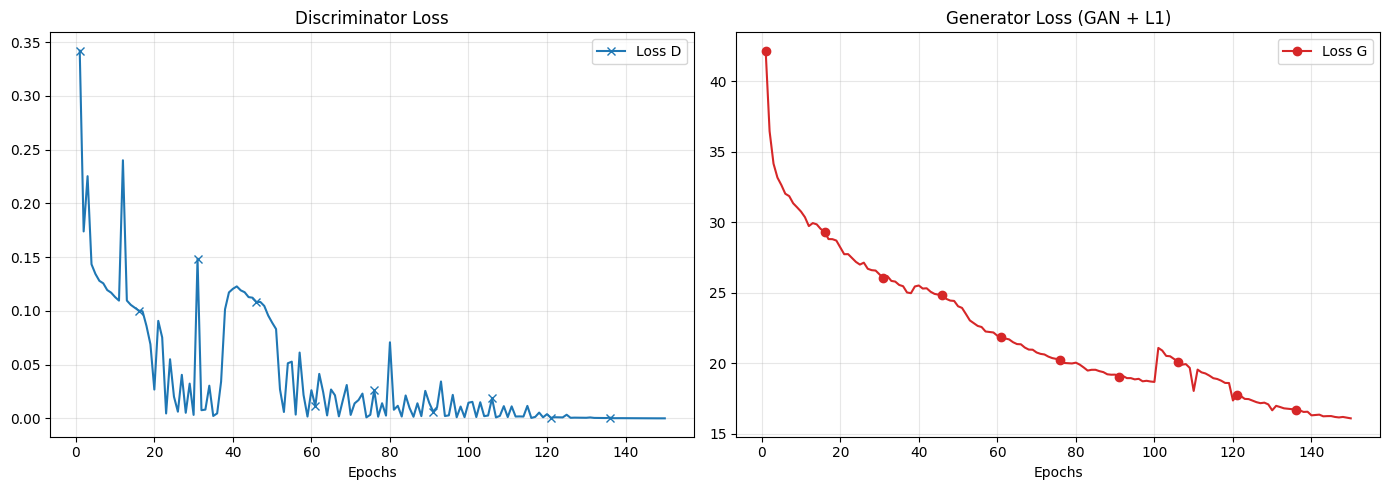

Grafico salvato in: /kaggle/working/eagans_metrics_plot.png


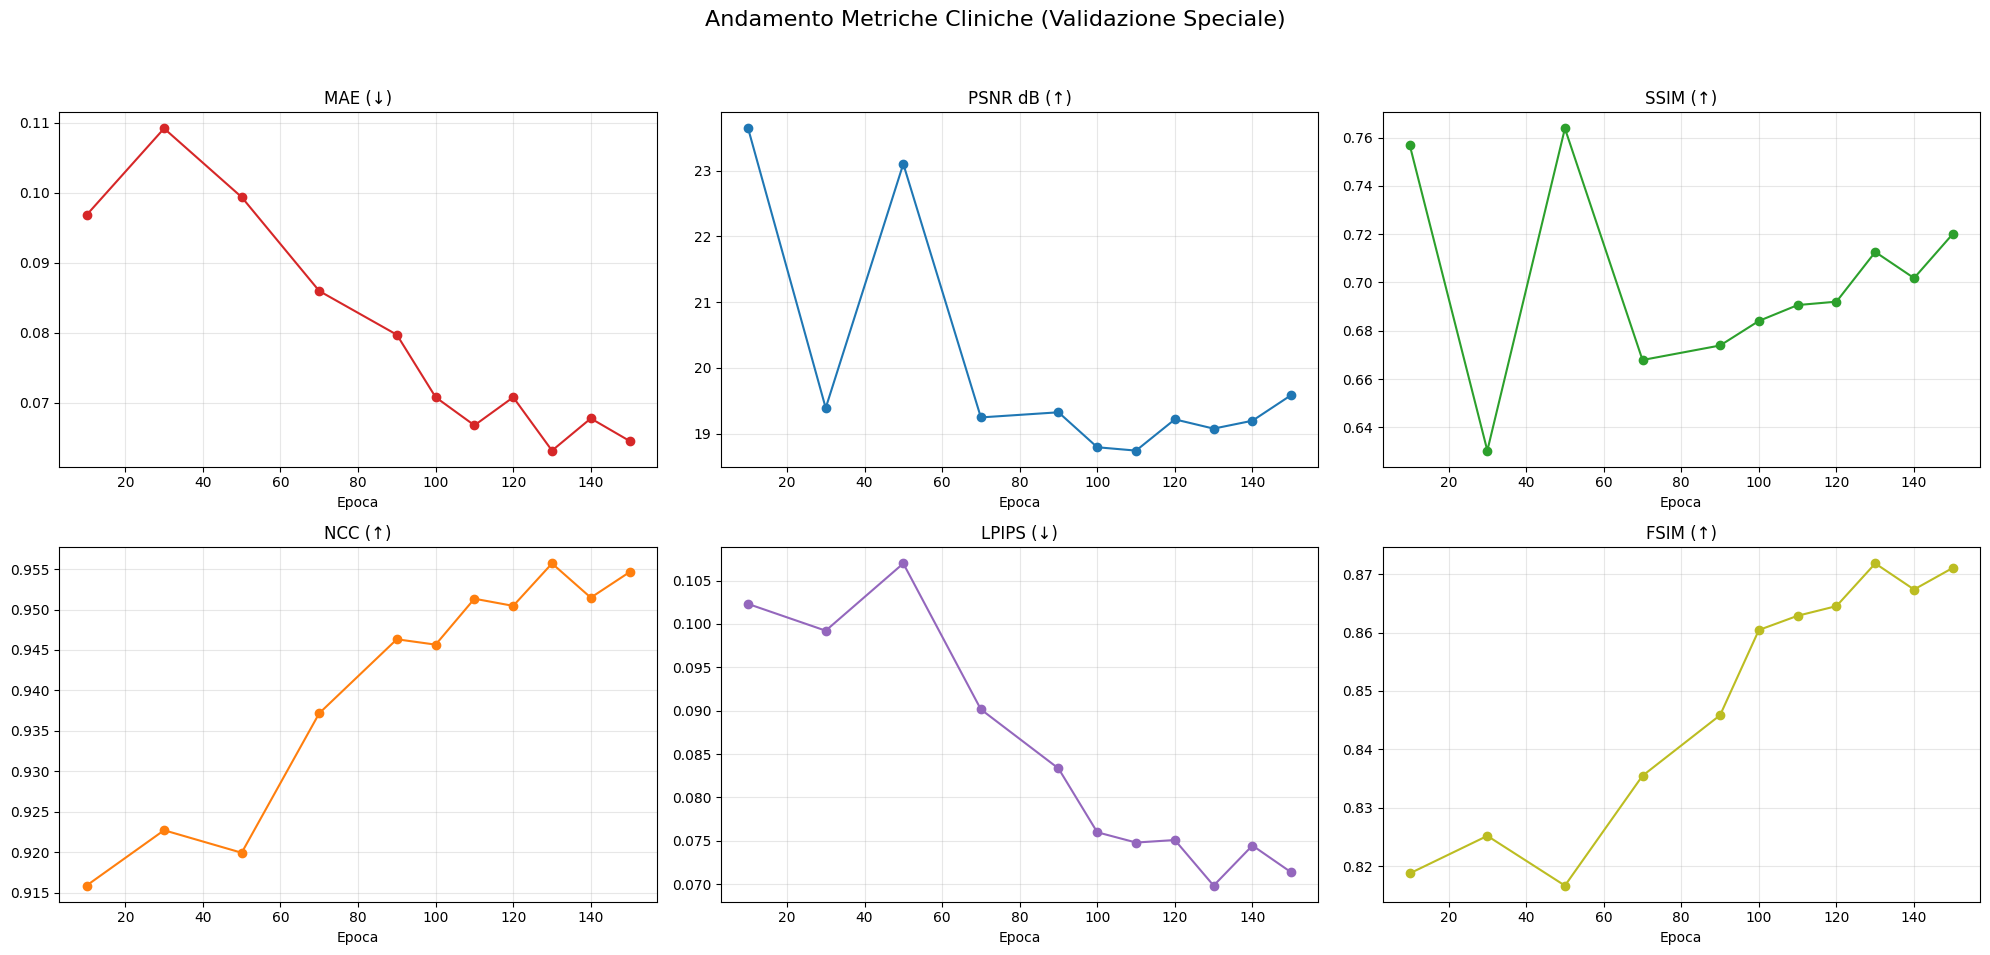

In [20]:
modello_Generatore, modello_Discriminatore, check_G, check_D, H_G, H_D = train_pix2pix3d_patch_optimized(
    subjects_list_train = subjects_train,
    epochs=150,
    epoche_fixed_lr= 100,
    lambda_L1=300,
    batch_size=8,
    lr_G=2e-4,
    lr_D=2e-4,
    patches_per_pat = 8,
    patch_size=(128, 128, 128),
    queue_max_lenght = 100,
    checkpoint_path='/kaggle/input/models/giuliasteiner/model-pix2pix-128-t1-flair/pytorch/default/8/checkpoint_eagan_139.pth',
    dataset_val = dataset_val,
    eval_every = 10,
)
torch.save(modello_Generatore.state_dict(), 'G_pix2pix_128.pth')